In [1]:
import bmll2 as b2
from bmll2 import reference, Security, NormalisedSecurity, SparkHelper, get_market_data, get_market_data_range, VenueMarketError, get_market_tables, save_spark_dataframe, load_spark_dataframe
import random
import math
import pandas as pd
import polars as pl
import numpy as np
from pandas import StringDtype
import gc
from typing import Literal

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogFormatterSciNotation
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy.stats import t

In [2]:
b2.get_file('top_250.csv')
top_250 = pd.read_csv('top_250.csv')

top_250_tickers = top_250['Ticker'].tolist()

files = b2.list_files(path = 'data/trades/top_250')

for f in files:
    b2.get_file(f'data/trades/top_250/{f}')

exchange = 'XJSE'

In [3]:
def load_stock(parquet):
    try:
        df = pl.read_parquet(parquet)
        return df.sort(['DateTime', 'ExchangeSequenceNo'])
    except FileNotFoundError:
        return None
        
stocks = {
    ticker: df
    for ticker in top_250_tickers
    if (df := load_stock(f'{ticker}_{exchange}.parquet')) is not None
}

In [4]:
stock_ADV = pl.scan_parquet(f'*_{exchange}.parquet').select(['Ticker', 'Date', '20 AD volume', '20 AD volatility']).collect()
stock_ADV = stock_ADV.unique(keep = 'first')
stock_ADV = stock_ADV.sort(['Ticker', 'Date'])
stock_ADV = stock_ADV.group_by('Ticker').agg([pl.col('20 AD volume').mean().alias('20 AD volume'),
                                              pl.col('20 AD volatility').mean().alias('20 AD volatility')])

In [5]:
def compute_stock_acf(stock_data: pl.DataFrame, column: Literal['Trade Sign', 'Mid-price (diff)', 'log return'],
                      group_col: Literal['Date', 'TradeDate'], group: Literal['day', 'month', 'year'], 
                      nlags: int = 1000):


    if group == 'day':
        stock_data = stock_data.with_columns(pl.col(group_col).alias('group key'))

    elif group == 'month':
        stock_data = stock_data.with_columns(pl.col(group_col).dt.truncate('1mo').alias('group key'))
    
    elif group == 'year':
        stock_data = stock_data.with_columns(pl.col(group_col).dt.truncate('1y').alias('group key'))

    max_possible_lag = stock_data.group_by('group key').len()['len'].max() - 1
    nlags            = min(nlags, max_possible_lag)

    acf_list = []
    for _, group in stock_data.group_by('group key'):

        if group_col == 'Date':
            group = group.sort(['DateTime', 'ExchangeSequenceNo'], descending = False)

        if group_col == 'TradeDate':
            group = group.sort(['LocalTimestamp', 'ExchangeSequenceNo'], descending = False) 
            
        series = group[column].drop_nulls().to_numpy()

        #current_lags = min(max_possible_lag, len(series) - 1)
        if len(series) < 2:
            continue
        current_lags = max(0, min(max_possible_lag, len(series) - 1))
        acf_vals     = acf(series, nlags = current_lags, fft = True)[1 : (nlags + 1)]

        if current_lags < nlags:
            acf_vals = np.pad(acf_vals, (0, nlags - current_lags), constant_values = np.nan)

        acf_list.append(acf_vals)


    if not acf_list:
        return None

    acf_array = np.vstack(acf_list)

    valid_counts =  np.sum(~np.isnan(acf_array), axis = 0)

    mean_acf  = np.nanmean(acf_array, axis = 0)
    std_acf   = np.nanstd(acf_array, axis = 0, ddof = 1)
    #n_eff     = np.sum(~np.isnan(acf_array), axis = 0)
    se_acf    = std_acf / np.sqrt(valid_counts)
    
    mean_acf[valid_counts == 0] = np.nan
    se_acf[valid_counts == 0]   = np.nan

    return mean_acf, se_acf
    

In [7]:
b2.create_folder('data', ensure_exists = True)
b2.create_folder('data/ACF', ensure_exists = True)
b2.create_folder(f'data/ACF/{exchange}', ensure_exists = True)

group  = 'month'
column = 'Trade Sign'
nlags  = 5000

if column == 'Trade Sign':
    identifier = f'ts_{nlags}_{group}_pl'
if column == 'Mid-price (diff)':
    identifier = f'mp_{nlags}_{group}_pl'

In [13]:
%%time
acf_results = {}
counter = 0
for ticker, data in stocks.items():

    counter += 1
    
    result = compute_stock_acf(data, column = column, group_col = 'Date', group = group, nlags = nlags)

    if result is not None:
        print(f'{counter}: {ticker}')
        mean_acf, se_acf = result
        acf_results[ticker] = {'mean acf': mean_acf, 'se acf': se_acf}

rows = []

for ticker, values in acf_results.items():

    mean_acf = values['mean acf']
    se_acf   = values['se acf']
    nlags    = len(mean_acf)

    ADVolume_value     = stock_ADV.filter(pl.col('Ticker') == ticker).select('20 AD volume').item()
    ADVolatility_value = stock_ADV.filter(pl.col('Ticker') == ticker).select('20 AD volatility').item()
    

    for tau in range(nlags):

        acf_val = mean_acf[tau]
        acf_se  = se_acf[tau]

        if acf_val > 0:
            rows.append({'Ticker': ticker, 'tau': tau + 1, 'acf': acf_val, 'se acf': acf_se,
                         '20 AD volume': ADVolume_value, '20 AD volatility': ADVolatility_value})

master_ACF_ts = pl.DataFrame(rows)
master_ACF_ts.write_parquet(f'{exchange}_master_ACF_{identifier}.parquet')
b2.put_file(f'{exchange}_master_ACF_{identifier}.parquet', f'data/ACF/{exchange}')


1: BHG
2: BTI
3: ANH
4: PRX
5: CFR
6: GLN
7: AGL
8: ANG
9: NPN
10: GFI
11: SBK
12: FSR
13: CPI
14: VAL
15: MTN
16: VOD
17: IMP
18: S32
19: ABG
20: SLM
21: DSY
22: HAR
23: SHP
24: SSW
25: NPH
26: BID
27: NED
28: SOL
29: OUT
30: RNI
31: KIO
32: NRP
33: REM
34: INP
35: PPH
36: MNP
37: BVT
38: PAN
39: EXX
40: CLS
41: OMU
42: CCO
43: APN
44: GRT
45: QLT
46: WHL
47: TBS
48: MTM
49: SNT
50: ARI
51: MRP
52: DRD
53: RDF
54: HMN
55: INL
56: AVI
57: SRE
58: N91
59: BOX
60: KST
61: TKG
62: VKE
63: RES
64: DCP
65: FFB
66: KRO
67: OPA
68: TFG
69: SRI
70: PMR
71: TGA
72: HYP
73: TRU
74: ADH
75: MTH
76: APH
77: NTC
78: WBC
79: CML
80: LHC
81: NY1
82: DTC
83: LTE
84: BYI
86: EQU
87: MSP
88: OMN
89: JSE
90: PIK
91: HCI
92: ATT
93: GND
94: SPP
95: ITE
96: AFE
97: RLO
98: WBO
99: ARL
100: ISO
101: SUI
102: SAP
103: CVW
104: AFH
105: SDO
106: PPC
107: SAC
108: SSS
109: RBX
110: BLU
111: AEL
112: BAT
113: RCL
114: THA
115: CLI
116: IPF
117: HIL
118: HET
119: OCE
120: TSG
121: CAA
122: DIB
123: RFG
124: EMI


/tmp/ipykernel_12633/419097859.py:48: RuntimeWarning:

Mean of empty slice



222: EMH
223: KBO
224: AON
225: TRL
226: NCS
227: TLM
228: RHB
229: LAB
230: RNG
231: SEB
232: BIK
233: GLI
234: RTO
235: VIS
237: EUZ
238: EEL
239: ADW
CPU times: user 1min 58s, sys: 17.8 s, total: 2min 16s
Wall time: 40.2 s


In [9]:
b2.create_folder('data', ensure_exists = True)
b2.create_folder('data/ACF', ensure_exists = True)
b2.create_folder(f'data/ACF/{exchange}', ensure_exists = True)


group  = 'month'
column = 'Mid-price (diff)'
nlags  = 5000

if column == 'Trade Sign':
    identifier = f'ts_{nlags}_{group}_pl'
if column == 'Mid-price (diff)':
    identifier = f'mp_{nlags}_{group}_pl'

In [10]:
%%time
acf_results = {}
counter = 0
for ticker in top_250_tickers:
    counter += 1
    stock_mid_prices = get_market_data_range('XJSE', start_date = '2023-01-03', end_date = '2025-12-31',
                                             table_name = 'l1', ticker = ticker, df_engine = 'polars',
                                             columns = ['Ticker', 'TradeDate', 'LocalTimestamp', 'BidPrice1',
                                                        'AskPrice1', 'ExchangeSequenceNo', 'MarketState'])
   
    if stock_mid_prices is None or stock_mid_prices.is_empty():
        continue
        
    stock_mid_prices = stock_mid_prices.filter(pl.col('MarketState') == 'CONTINUOUS_TRADING')
    stock_mid_prices = stock_mid_prices.sort(['LocalTimestamp', 'ExchangeSequenceNo'])
    stock_mid_prices = stock_mid_prices.with_columns(((pl.col('BidPrice1') + pl.col('AskPrice1')) / 2).diff().alias('Mid-price (diff)'))
    stock_mid_prices = stock_mid_prices.sort(['LocalTimestamp', 'ExchangeSequenceNo'])   
    
    result = compute_stock_acf(stock_data = stock_mid_prices, column = column,
                               group_col = 'TradeDate', group = group, nlags = nlags)

    del stock_mid_prices
    gc.collect()

    if result is not None:
        print(f'{counter}: {ticker}')
        mean_acf, se_acf = result
        acf_results[ticker] = {'mean acf': mean_acf, 'se acf': se_acf}

# takes 45 minutes when using month

rows = []

for ticker, values in acf_results.items():

    mean_acf = values['mean acf']
    se_acf   = values['se acf']
    nlags    = len(mean_acf)

    ADVolume_value     = stock_ADV.filter(pl.col('Ticker') == ticker).select('20 AD volume').item()
    ADVolatility_value = stock_ADV.filter(pl.col('Ticker') == ticker).select('20 AD volatility').item()
    

    for tau in range(nlags):

        acf_val = mean_acf[tau]
        acf_se  = se_acf[tau]

        if acf_val > 0:
            rows.append({'Ticker': ticker, 'tau': tau + 1, 'acf': acf_val, 'se acf': acf_se,
                         '20 AD volume': ADVolume_value, '20 AD volatility': ADVolatility_value})

master_ACF_ts = pl.DataFrame(rows)
master_ACF_ts.write_parquet(f'{exchange}_master_ACF_{identifier}.parquet')
b2.put_file(f'{exchange}_master_ACF_{identifier}.parquet', f'data/ACF/{exchange}')


1: BHG
2: BTI
3: ANH
4: PRX
5: CFR
6: GLN
7: AGL
8: ANG
9: NPN
10: GFI
11: SBK
12: FSR
13: CPI
14: VAL
15: MTN
16: VOD
17: IMP
18: S32
19: ABG
20: SLM
21: DSY
22: HAR
23: SHP
24: SSW
26: NPH
27: BID
28: NED
29: SOL
30: OUT
32: RNI
33: KIO
34: NRP
35: REM
36: INP
37: PPH
38: MNP
39: BVT
40: PAN
41: EXX
42: CLS
43: OMU
44: CCO
45: APN
46: GRT
47: QLT
48: WHL
49: TBS
50: MTM
51: SNT
52: ARI
53: MRP
54: DRD
55: RDF
56: HMN
57: INL
58: AVI
59: SRE
60: N91
61: BOX
62: KST
63: TKG
64: VKE
65: RES
66: DCP
67: FFB
68: KRO
69: OPA
70: TFG


/tmp/ipykernel_14288/419097859.py:48: RuntimeWarning:

Mean of empty slice

/home/bmll/.conda/envs/py311-stable/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.



71: SRI
72: PMR
73: TGA
74: HYP
75: TRU
76: ADH
77: MTH
78: APH
79: NTC
80: WBC
81: CML
82: LHC
83: NY1
84: DTC
85: LTE
86: BYI
87: GTC
88: EQU
89: MSP
90: OMN
91: JSE
92: PIK
93: HCI
94: ATT
95: GND
97: SPP
98: ITE
99: AFE
100: RLO
101: WBO
102: ARL
103: ISO
104: SUI
105: SAP
106: CVW
107: AFH
108: SDO
109: PPC
110: SAC
111: SSS
112: RBX
113: BLU
114: AEL
115: BAT
116: RCL
117: THA
118: CLI
119: IPF
120: HIL
121: HET
122: OCE
124: TSG
125: CAA
126: DIB
127: RFG
128: EMI
129: RBO
130: HDC
131: AFT
132: SPG
133: SBP
134: EXP
135: SEA
136: FBR
137: ACS
138: CAT
139: KAP
140: SYG
141: LEW
142: KP2
143: OCT
144: NPK
145: BEL
146: CHP
147: SUR
148: TDH
149: SHG
150: CSB
151: KAL
152: MPT
153: IVT
154: MRF
155: PPE
156: ORN
157: LBR
158: EOH
159: CMH
160: MDI
161: JBL
162: OAO
163: CLH
164: SDL
165: ZZD
166: YYLBEE
167: CTA
168: QFH
169: GML
170: ZED
171: SCD
172: NVS
173: ART
175: BWN
176: OAS
177: APF
178: MMP
179: EPS
180: EMN
181: MCZ
182: ACL
183: BRN
184: UPL
186: TPC
187: BCF
188: TEX

/home/bmll/.conda/envs/py311-stable/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning:

invalid value encountered in divide



233: KBO
234: AON
235: TRL
236: NCS
237: TLM
238: RHB
240: LAB
241: RNG
242: SEB
243: BIK
244: GLI
245: RTO
246: VIS
247: AOO
248: EUZ
249: EEL
250: ADW
CPU times: user 1h 30min 19s, sys: 33min 29s, total: 2h 3min 48s
Wall time: 1h 35min


In [9]:
b2.create_folder('data', ensure_exists = True)
b2.create_folder('data/ACF', ensure_exists = True)
b2.create_folder(f'data/ACF/{exchange}', ensure_exists = True)


group  = 'day'
column = 'log return'
nlags  = 5000

if column == 'Trade Sign':
    identifier = f'ts_{nlags}_{group}_pl'
if column == 'Mid-price (diff)':
    identifier = f'mp_{nlags}_{group}_pl'
if column == 'log return':
    identifier = f'lr_{nlags}_{group}_pl'

In [10]:
%%time
acf_results = {}
counter = 0
for ticker in top_250_tickers:
    counter += 1
    stock_mid_prices = get_market_data_range('XJSE', start_date = '2023-01-03', end_date = '2025-12-31',
                                             table_name = 'l1', ticker = ticker, df_engine = 'polars',
                                             columns = ['Ticker', 'TradeDate', 'LocalTimestamp', 'BidPrice1',
                                                        'AskPrice1', 'ExchangeSequenceNo', 'MarketState'])
   
    if stock_mid_prices is None or stock_mid_prices.is_empty():
        continue
        
    stock_mid_prices = stock_mid_prices.filter(pl.col('MarketState') == 'CONTINUOUS_TRADING')
    stock_mid_prices = stock_mid_prices.sort(['LocalTimestamp', 'ExchangeSequenceNo'])
    stock_mid_prices = stock_mid_prices.with_columns(((pl.col('BidPrice1') + pl.col('AskPrice1')) / 2).log().diff().alias('log return'))
    stock_mid_prices = stock_mid_prices.sort(['LocalTimestamp', 'ExchangeSequenceNo'])   
    
    result = compute_stock_acf(stock_data = stock_mid_prices, column = column,
                               group_col = 'TradeDate', group = group, nlags = nlags)

    del stock_mid_prices
    gc.collect()

    if result is not None:
        print(f'{counter}: {ticker}')
        mean_acf, se_acf = result
        acf_results[ticker] = {'mean acf': mean_acf, 'se acf': se_acf}

# takes 45 minutes when using month

rows = []

for ticker, values in acf_results.items():

    mean_acf = values['mean acf']
    se_acf   = values['se acf']
    nlags    = len(mean_acf)

    ADVolume_value     = stock_ADV.filter(pl.col('Ticker') == ticker).select('20 AD volume').item()
    ADVolatility_value = stock_ADV.filter(pl.col('Ticker') == ticker).select('20 AD volatility').item()
    

    for tau in range(nlags):

        acf_val = mean_acf[tau]
        acf_se  = se_acf[tau]

        if acf_val > 0:
            rows.append({'Ticker': ticker, 'tau': tau + 1, 'acf': acf_val, 'se acf': acf_se,
                         '20 AD volume': ADVolume_value, '20 AD volatility': ADVolatility_value})

master_ACF_ts = pl.DataFrame(rows)
master_ACF_ts.write_parquet(f'{exchange}_master_ACF_{identifier}.parquet')
b2.put_file(f'{exchange}_master_ACF_{identifier}.parquet', f'data/ACF/{exchange}')


1: BHG
2: BTI
3: ANH
4: PRX
5: CFR
6: GLN
7: AGL
8: ANG
9: NPN
10: GFI
11: SBK
12: FSR
13: CPI
14: VAL
15: MTN
16: VOD
17: IMP
18: S32
19: ABG
20: SLM
21: DSY
22: HAR
23: SHP
24: SSW
26: NPH
27: BID
28: NED
29: SOL
30: OUT
32: RNI
33: KIO
34: NRP
35: REM
36: INP
37: PPH
38: MNP
39: BVT
40: PAN
41: EXX
42: CLS
43: OMU
44: CCO
45: APN
46: GRT
47: QLT
48: WHL
49: TBS
50: MTM
51: SNT
52: ARI
53: MRP
54: DRD
55: RDF
56: HMN
57: INL
58: AVI
59: SRE
60: N91
61: BOX
62: KST
63: TKG
64: VKE
65: RES
66: DCP
67: FFB
68: KRO
69: OPA
70: TFG
71: SRI
72: PMR
73: TGA
74: HYP
75: TRU
76: ADH
77: MTH
78: APH
79: NTC
80: WBC
81: CML
82: LHC
83: NY1
84: DTC
85: LTE
86: BYI


/tmp/ipykernel_7750/2877470837.py:48: RuntimeWarning:

Mean of empty slice



87: GTC
88: EQU
89: MSP
90: OMN
91: JSE
92: PIK
93: HCI
94: ATT
95: GND
97: SPP
98: ITE
99: AFE
100: RLO
101: WBO
102: ARL
103: ISO
104: SUI
105: SAP
106: CVW
107: AFH
108: SDO
109: PPC
110: SAC
111: SSS
112: RBX
113: BLU
114: AEL
115: BAT
116: RCL
117: THA
118: CLI
119: IPF
120: HIL
121: HET
122: OCE
124: TSG
125: CAA
126: DIB
127: RFG
128: EMI
129: RBO
130: HDC
131: AFT
132: SPG
133: SBP
134: EXP
135: SEA
136: FBR
137: ACS
138: CAT
139: KAP
140: SYG
141: LEW
142: KP2
143: OCT
144: NPK
145: BEL
146: CHP
147: SUR
148: TDH
149: SHG
150: CSB
151: KAL
152: MPT
153: IVT
154: MRF
155: PPE
156: ORN
157: LBR
158: EOH
159: CMH
160: MDI
161: JBL
162: OAO
163: CLH
164: SDL
165: ZZD
166: YYLBEE
167: CTA
168: QFH
169: GML
170: ZED
171: SCD
172: NVS
173: ART
175: BWN
176: OAS
177: APF
178: MMP
179: EPS
180: EMN
181: MCZ
182: ACL
183: BRN
184: UPL
186: TPC
187: BCF
188: TEX
189: DNB
190: EPE
191: TCP
192: SSK
193: YRK
194: GPL
195: SNV
196: MST
197: MTA
198: WEZ
199: PBG
200: ENX
201: HLM
202: ACT
2

In [2]:
group  = 'month'
column = 'log return'
nlags  = 5000
exchange = 'XJSE'

if column == 'Trade Sign':
    identifier = f'ts_{nlags}_{group}_pl'
if column == 'Mid-price (diff)':
    identifier = f'mp_{nlags}_{group}_pl'
if column == 'log return':
    identifier = f'lr_{nlags}_{group}_pl'

In [3]:
b2.get_file(f'data/ACF/{exchange}/{exchange}_master_ACF_{identifier}.parquet')
acf = pl.read_parquet(f'{exchange}_master_ACF_{identifier}.parquet')

In [44]:
def master_ACF_model(x, delta, gamma):
    sigma = x['20 AD volatility']
    lags  = x['tau']
    return  sigma ** delta * lags ** gamma

In [4]:
acf

Ticker,tau,acf,se acf,20 AD volume,20 AD volatility
str,i64,f64,f64,f64,f64
"""BHG""",6,0.00486,0.002273,424794.358897,0.019355
"""BHG""",12,0.001175,0.00245,424794.358897,0.019355
"""BHG""",14,0.002458,0.002406,424794.358897,0.019355
"""BHG""",15,0.001322,0.002192,424794.358897,0.019355
"""BHG""",18,0.00248,0.001505,424794.358897,0.019355
…,…,…,…,…,…
"""ADW""",2469,0.007224,NaN,30008.597227,0.02004
"""ADW""",2472,0.027446,NaN,30008.597227,0.02004
"""ADW""",2476,0.002974,NaN,30008.597227,0.02004


In [5]:
acf = acf.with_columns((pl.col('acf') * pl.col('20 AD volume')).alias('acf scaled'))
acf = acf.with_columns((pl.col('se acf') * pl.col('20 AD volume')).alias('se scaled'))

In [6]:
x = acf['tau'].to_numpy()
y = acf['acf'].to_numpy()

binned = acf.group_by('tau').agg((pl.col('acf scaled').sum() / pl.col('20 AD volume').sum()).alias('acf (ADV weighted)'),
                                  (pl.col('se scaled').sum() / pl.col('20 AD volume').sum()).alias('se (ADV weighted)'),
                                  pl.col('tau').count().alias('n obs')).sort('tau')


In [7]:
b2.create_folder('figures_2', ensure_exists = True)
b2.create_folder('figures_2/ACF', ensure_exists = True)
b2.create_folder(f'figures_2/ACF/{exchange}', ensure_exists = True)

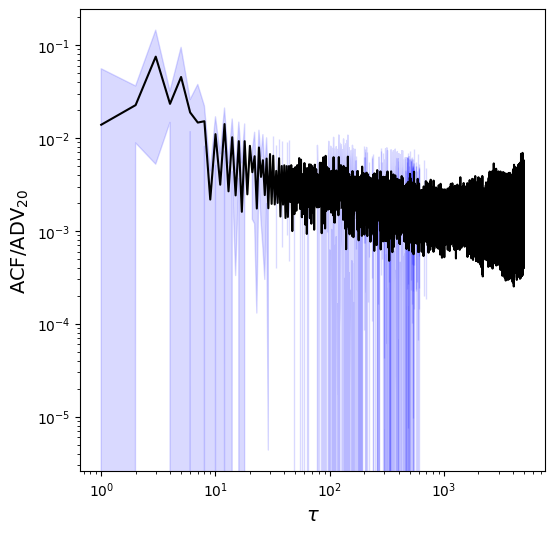

In [8]:
plt.figure(figsize = (6, 6))
plt.plot(binned['tau'], binned['acf (ADV weighted)'], linestyle = '-', color = 'black')
plt.fill_between(binned['tau'], binned['acf (ADV weighted)'] - binned['se (ADV weighted)'],
                 binned['acf (ADV weighted)'] + binned['se (ADV weighted)'], alpha = 0.15, color = 'blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tau$', fontsize = 14)
plt.ylabel(r'$\mathrm{ACF}/\mathrm{ADV}_{\mathrm{20}}$', fontsize = 14)

#plt.savefig(f'{exchange}_master_ACF_{identifier}.pdf')
#b2.put_file(f'{exchange}_master_ACF_{identifier}.pdf', f'figures_2/ACF/{exchange}')
#b2.get_file(f'figures_2/ACF/{exchange}/{exchange}_master_ACF_{identifier}.pdf')

plt.show()

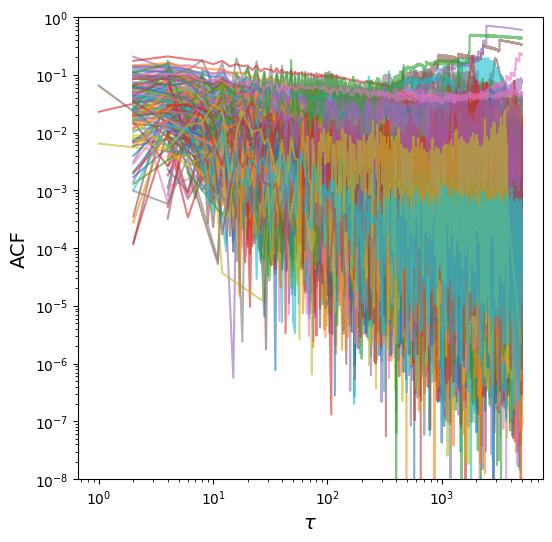

In [9]:
plt.figure(figsize = (6, 6))

for ticker, group in acf.group_by('Ticker'):
    tau        = group['tau']
    acf_vals   = group['acf']
    plt.plot(tau, acf_vals, alpha = 0.6, label = ticker)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tau$', fontsize = 14)
plt.ylabel('ACF', fontsize = 14)
plt.ylim(1e-8, 1)

#plt.savefig(f'{exchange}_individual_ACFs_{identifier}.pdf')
#b2.put_file(f'{exchange}_individual_ACFs_{identifier}.pdf', f'figures_2/ACF/{exchange}')
#b2.get_file(f'figures_2/ACF/{exchange}/{exchange}_individual_ACFs_{identifier}.pdf')

plt.show()